In [1]:
# Cell 0

# If you don't already have these, uncomment and run this cell once.
# !pip install nfl_data_py scikit-learn xgboost joblib pyyaml

In [2]:
# Cell 1

# ===== Config you change weekly =====
TARGET_SEASON = 2025
TARGET_WEEK   = 2

# History window for training
TRAIN_SEASONS = list(range(2018, 2025))  # 2018–2024

# Paths
OUTDIR   = "outputs"
MODELDIR = "models"

# Reproducibility
SEED = 42

# ===== Imports =====
import warnings, json, math
from pathlib import Path
from functools import lru_cache
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ML
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
import joblib

# nfl_data_py
try:
    import nfl_data_py as nfl
except Exception as e:
    print("nfl_data_py not found; install and restart the kernel to run end-to-end.")
    nfl = None

# Folders
Path(OUTDIR).mkdir(parents=True, exist_ok=True)
Path(MODELDIR).mkdir(parents=True, exist_ok=True)

print(f"XGBoost available: {XGB_AVAILABLE}")
print(f"Training seasons : {TRAIN_SEASONS}")
print(f"Target           : {TARGET_SEASON} Week {TARGET_WEEK}")

XGBoost available: True
Training seasons : [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Target           : 2025 Week 2


In [3]:
# Cell 2

# Half-PPR defaults; adjust as you like
SCORING = {
    "rushing_yards_per_point":   0.1,  # 1 pt per 10 rush yards
    "rushing_td":                6.0,
    "receptions":                0.5,  # half-PPR
    "receiving_yards_per_point": 0.1,  # 1 pt per 10 rec yards
    "receiving_td":              6.0,
    "fumbles_lost":             -2.0,
    "two_pt":                    2.0,
}

def _col(df, candidates, default_name=None):
    """Return the first column that exists from candidates; else create a zero column."""
    for c in candidates:
        if c in df.columns:
            return c
    if default_name is None:
        default_name = candidates[0]
    df[default_name] = 0.0
    return default_name

def compute_rb_fantasy_points(df: pd.DataFrame, scoring: dict) -> pd.Series:
    """
    Compute fantasy points for RBs using nfl_data_py column names (with fallbacks).
    """
    # Canonical nfl_data_py weekly names we’ll resolve:
    c_rush_yds = _col(df, ["rushing_yards","rush_yds"])
    c_rush_td  = _col(df, ["rushing_tds","rush_td"])
    c_rec      = _col(df, ["receptions","rec"])
    c_rec_yds  = _col(df, ["receiving_yards","rec_yds"])
    c_rec_td   = _col(df, ["receiving_tds","rec_td"])
    c_fum_lost = _col(df, ["fumbles_lost","fum_lost","fumbles"])
    c_two_pt   = _col(df, ["two_point_conversions","two_pt_md","two_pt"])

    pts = (
        df[c_rush_yds].astype(float) * scoring["rushing_yards_per_point"]
        + df[c_rush_td].astype(float) * scoring["rushing_td"]
        + df[c_rec].astype(float)      * scoring["receptions"]
        + df[c_rec_yds].astype(float) * scoring["receiving_yards_per_point"]
        + df[c_rec_td].astype(float)   * scoring["receiving_td"]
        + df[c_two_pt].astype(float)   * scoring["two_pt"]
        + df[c_fum_lost].astype(float) * scoring["fumbles_lost"]
    )
    return pts

In [4]:
# Cell 3

# These handle version differences in nfl_data_py (years vs seasons vs positional args)
def _try_import(callable_obj, years):
    import pandas as pd
    try:
        return callable_obj(years=years)
    except TypeError:
        pass
    try:
        return callable_obj(seasons=years)
    except TypeError:
        pass
    try:
        return callable_obj(years)  # positional
    except TypeError:
        pass
    try:
        return callable_obj()       # last resort
    except Exception:
        return pd.DataFrame()

@lru_cache(maxsize=None)
def load_weekly(seasons_tuple):
    import pandas as pd
    if nfl is None:
        return pd.DataFrame()
    years = list(seasons_tuple)
    try:
        return _try_import(nfl.import_weekly_data, years)
    except Exception as e:
        print("load_weekly failed:", e)
        return pd.DataFrame()

@lru_cache(maxsize=None)
def load_schedules(seasons_tuple):
    import pandas as pd
    if nfl is None:
        return pd.DataFrame()
    years = list(seasons_tuple)
    try:
        return _try_import(nfl.import_schedules, years)
    except Exception as e:
        print("load_schedules failed:", e)
        return pd.DataFrame()

@lru_cache(maxsize=None)
def load_lines(seasons_tuple):
    import pandas as pd
    if nfl is None:
        return pd.DataFrame()
    years = list(seasons_tuple)

    for fn_name in ["import_lines", "import_betting_lines", "import_book_lines"]:
        try:
            fn = getattr(nfl, fn_name, None)
            if fn is None:
                continue
            df = _try_import(fn, years)
            if df is not None and not df.empty:
                return df
        except Exception:
            continue
    return pd.DataFrame()

def safe_merge(left, right, on, how="left"):
    import pandas as pd
    if left is None:
        return pd.DataFrame()
    if isinstance(left, pd.DataFrame) and left.empty:
        return left
    if right is None or (isinstance(right, pd.DataFrame) and right.empty):
        return left
    return pd.merge(left, right, on=on, how=how)

In [5]:
# Cell 4

def expand_to_team_rows(df: pd.DataFrame,
                        home_key_candidates=("team_home","home_team","home","team_h"),
                        away_key_candidates=("team_away","away_team","away","team_a")) -> pd.DataFrame:
    """
    Convert game-level schedules/lines (one row per game) into a team-centric table
    with one row per team per game (home & away).
    """
    import pandas as pd
    if df is None or df.empty:
        return pd.DataFrame()

    def pick(cands):
        for c in cands:
            if c in df.columns:
                return c
        return None

    hk = pick(home_key_candidates)
    ak = pick(away_key_candidates)

    # If it's already team-centric, just return a safe subset
    if hk is None or ak is None:
        if "team" in df.columns and "opp_team" in df.columns:
            out = df.copy()
            if "home_away" not in out.columns:
                out["home_away"] = np.where(out.get("team")==out.get("team_home",""), "home", "away")
            return out
        print("WARNING expand_to_team_rows: could not find home/away keys; returning empty.")
        return pd.DataFrame()

    home = df.copy()
    home["team"] = home[hk]
    home["opp_team"] = home[ak]
    home["home_away"] = "home"

    away = df.copy()
    away["team"] = away[ak]
    away["opp_team"] = away[hk]
    away["home_away"] = "away"

    return pd.concat([home, away], ignore_index=True)

In [6]:
# Cell 4 and a half

# === Team code normalization across data sources ===
TEAM_FIX = {
    # legacy 3-letter → modern 2/3-letter
    "GNB": "GB",
    "KAN": "KC",
    "NWE": "NE",
    "TAM": "TB",
    "SFO": "SF",
    "NOR": "NO",
    "CLV": "CLE",
    "BLT": "BAL",
    "JAX": "JAC",
    "OAK": "LV",
    "SD":  "LAC",
    "STL": "LAR",
    "HOU": "HOU",  # no-op examples
    "ARI": "ARI",
    "IND": "IND",
    "WSH": "WAS",  # older Washington
    # sometimes books/sources say "LA" without specifying; we leave "LA" as-is
    # because it may be what your schedules use in 2025. We’ll try to keep it.
    # If your weekly history uses LAR/LAC, we’ll attempt a soft match later.
}

def normalize_team_codes(df: pd.DataFrame, cols=("team","opp_team")) -> pd.DataFrame:
    """
    Map legacy/variant team abbreviations to schedule-style codes.
    Operates in-place and returns df for chaining.
    """
    if df is None or df.empty:
        return df
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.upper().map(lambda x: TEAM_FIX.get(x, x))
    return df

In [7]:
# Cell 5

def add_team_game_context(feat_df: pd.DataFrame, schedules: pd.DataFrame, lines: pd.DataFrame) -> pd.DataFrame:
    """
    Join schedule context (team, opp_team, home/away) and betting implied points (if available)
    to the player feature table. Team codes normalized to maximize join success.
    """
    import pandas as pd
    if feat_df is None or feat_df.empty:
        return pd.DataFrame()

    out = feat_df.copy()
    # Normalize on player side before any joins
    out = normalize_team_codes(out, cols=("team","opp_team"))

    # ---- Schedules ----
    s = schedules.copy()
    if s is not None and not s.empty:
        if "team" not in s.columns or "opp_team" not in s.columns:
            s = expand_to_team_rows(s)
        s = normalize_team_codes(s, cols=("team","opp_team"))

        if "home_away" not in s.columns:
            if "team_home" in s.columns and "team_away" in s.columns:
                s["home_away"] = np.where(s.get("team")==s.get("team_home"), "home",
                                   np.where(s.get("team")==s.get("team_away"), "away", np.nan))
            else:
                s["home_away"] = np.nan

        keep_sched = [c for c in ["season","week","team","opp_team","home_away"] if c in s.columns]
        s = s[keep_sched].drop_duplicates() if keep_sched else pd.DataFrame()
        out = safe_merge(out, s, on=[c for c in ["season","week","team"] if c in out.columns], how="left")

    # ---- Lines (optional) → implied totals ----
    if lines is not None and not lines.empty:
        L = lines.copy()
        if "team" not in L.columns or "opp_team" not in L.columns:
            L = expand_to_team_rows(L)
        L = normalize_team_codes(L, cols=("team","opp_team"))

        cand_spread = [c for c in ["spread_close","team_spread_close","spread_line","spread","team_spread"] if c in L.columns]
        cand_total  = [c for c in ["total_close","over_under_close","total_line","over_under_line","total"] if c in L.columns]

        L["__spread_use__"] = L[cand_spread[0]] if cand_spread else np.nan
        L["__total_use__"]  = L[cand_total[0]]  if cand_total  else np.nan

        L_use = L[[c for c in ["season","week","team","__spread_use__","__total_use__"] if c in L.columns]].copy()

        def implied_points(row):
            total  = row["__total_use__"]
            spread = row["__spread_use__"]
            if pd.isna(total) or pd.isna(spread):
                return np.nan, np.nan
            favorite_pts = (total / 2.0) - (spread / 2.0)
            underdog_pts = total - favorite_pts
            if spread < 0:
                return favorite_pts, underdog_pts
            else:
                return underdog_pts, favorite_pts

        implied = L_use.apply(lambda r: pd.Series(implied_points(r),
                                                  index=["vegas_implied_pts","vegas_opp_implied_pts"]), axis=1)
        L_use = pd.concat([L_use, implied], axis=1)
        out = safe_merge(out,
                         L_use[[c for c in ["season","week","team","vegas_implied_pts","vegas_opp_implied_pts"] if c in L_use.columns]],
                         on=[c for c in ["season","week","team"] if c in out.columns],
                         how="left")
    else:
        out["vegas_implied_pts"] = np.nan
        out["vegas_opp_implied_pts"] = np.nan

    ha = out["home_away"] if "home_away" in out.columns else pd.Series(np.nan, index=out.index)
    out["is_home"] = (ha.fillna("away") == "home").astype(int)
    return out

In [8]:
def _slice_week_schedule(schedules: pd.DataFrame, season: int, week: int) -> pd.DataFrame:
    s = schedules.copy()
    if s is None or s.empty:
        return pd.DataFrame()
    if "team" not in s.columns or "opp_team" not in s.columns:
        s = expand_to_team_rows(s)
    s = normalize_team_codes(s, cols=("team","opp_team"))
    keep = [c for c in ["season","week","team","opp_team","home_away","home_team","away_team"] if c in s.columns]
    s = s[keep].drop_duplicates()
    return s[(s["season"]==season) & (s["week"]==week)].copy()

def _vegas_team_implied(schedules: pd.DataFrame, lines: pd.DataFrame, season:int, week:int) -> pd.DataFrame:
    """
    Compute team-level implied points for (season, week).
    Priority:
      1) Use dedicated betting lines (import_lines/import_betting_lines/...) if present.
      2) Otherwise, use lines embedded in schedules (e.g., spread_line / over_under_line) if present.
    Orientation:
      - 'spread' is interpreted as HOME spread (negative => home favorite).
      - team_spread = spread if team is home else -spread.
      - team implied = total/2 - team_spread/2
    Returns columns: ['season','week','team','vegas_implied_pts']
    """
    import pandas as pd

    # --- Helper to compute implied from a team-centric frame with columns:
    # season, week, team, home_away, _spread (home spread), _total
    def _compute_from_team_lines(team_lines: pd.DataFrame) -> pd.DataFrame:
        TL = team_lines.copy()
        if TL.empty:
            return pd.DataFrame()
        TL["team_spread"] = np.where(TL["home_away"].eq("home"), TL["_spread"], -TL["_spread"])
        TL["vegas_implied_pts"] = TL["_total"]/2.0 - TL["team_spread"]/2.0
        return TL[["season","week","team","vegas_implied_pts"]].dropna(subset=["vegas_implied_pts"])

    # Always need a team-centric schedule slice for the week
    S = schedules.copy()
    if S is None or S.empty:
        return pd.DataFrame()
    if "team" not in S.columns or "opp_team" not in S.columns:
        S = expand_to_team_rows(S)
    S = normalize_team_codes(S, cols=("team","opp_team"))
    S_wk = S[(S["season"]==season) & (S["week"]==week)].copy()
    if S_wk.empty:
        return pd.DataFrame()

    # --- Path 1: dedicated lines table available
    if lines is not None and not lines.empty:
        L = lines.copy()
        if "team" not in L.columns or "opp_team" not in L.columns:
            L = expand_to_team_rows(L)
        L = normalize_team_codes(L, cols=("team","opp_team"))

        cand_spread = [c for c in ["spread_close","spread_line","team_spread_close","team_spread","spread"] if c in L.columns]
        cand_total  = [c for c in ["total_close","over_under_close","total_line","over_under_line","total"] if c in L.columns]
        if cand_spread and cand_total:
            Lwk = L[(L["season"]==season) & (L["week"]==week)][["season","week","team",cand_spread[0],cand_total[0]]]
            Lwk = Lwk.rename(columns={cand_spread[0]:"_spread", cand_total[0]:"_total"})
            # attach home_away from schedule so we can orient the spread to each team
            Lwk = Lwk.merge(S_wk[["season","week","team","home_away"]], on=["season","week","team"], how="left")
            Lwk["_spread"] = pd.to_numeric(Lwk["_spread"], errors="coerce")
            Lwk["_total"]  = pd.to_numeric(Lwk["_total"], errors="coerce")
            out = _compute_from_team_lines(Lwk)
            if not out.empty:
                return out

    # --- Path 2: use schedule-embedded lines if present (e.g., at game level)
    # Look for game-level columns like 'spread_line' / 'over_under_line'
    game_spread = next((c for c in ["spread_close","spread_line","home_spread","closing_spread","spread"] if c in S_wk.columns), None)
    game_total  = next((c for c in ["total_close","over_under_close","total_line","over_under_line","closing_total","total"] if c in S_wk.columns), None)
    if game_spread is not None and game_total is not None:
        # We need a team-centric frame where _spread is the HOME spread.
        G = S_wk.copy()
        G["_spread"] = pd.to_numeric(G[game_spread], errors="coerce")
        G["_total"]  = pd.to_numeric(G[game_total],  errors="coerce")
        # Some schedule exports put the spread only on 'home' rows; forward/backfill within each game_id
        if "game_id" in G.columns:
            G["_spread"] = G.groupby("game_id")["_spread"].transform("max")
            G["_total"]  = G.groupby("game_id")["_total"].transform("max")
        TL = G[["season","week","team","home_away","_spread","_total"]].dropna(subset=["_spread","_total"])
        out = _compute_from_team_lines(TL)
        if not out.empty:
            return out

    # No usable line source
    return pd.DataFrame()


In [9]:
# Cell 6

def rolling_player_features(weekly: pd.DataFrame, windows=(3,5), position="RB") -> pd.DataFrame:
    """
    Build rolling means for RB volume/production stats; leakage-safe (shift by 1).
    Uses nfl_data_py canonical columns with fallbacks.
    """
    import pandas as pd
    if weekly is None or weekly.empty:
        return pd.DataFrame()

    df = weekly.copy()
    if "position" in df.columns:
        df = df[df["position"] == position].copy()

    # Resolve canonical stat columns
    c_att     = _col(df, ["rushing_attempts","rush_att"])
    c_rush_yd = _col(df, ["rushing_yards","rush_yds"])
    c_rush_td = _col(df, ["rushing_tds","rush_td"])
    c_tgt     = _col(df, ["targets","tgt"])
    c_rec     = _col(df, ["receptions","rec"])
    c_rec_yd  = _col(df, ["receiving_yards","rec_yds"])
    c_rec_td  = _col(df, ["receiving_tds","rec_td"])

    essentials = [
        "player_id","player_name","recent_team","position","season","week",
        "opponent_team","home_away",
    ]
    for c in essentials:
        if c not in df.columns:
            df[c] = np.nan

    # Sort and index-safe
    df = df.sort_values(["player_id","season","week"]).reset_index(drop=True)

    grouped = df.groupby("player_id", group_keys=False)
    base_cols = {
        "rush_att": c_att,
        "rush_yds": c_rush_yd,
        "rush_td" : c_rush_td,
        "targets" : c_tgt,
        "rec"     : c_rec,
        "rec_yds" : c_rec_yd,
        "rec_td"  : c_rec_td,
    }

    # For each base stat and window, compute shifted rolling means directly into df
    for w in windows:
        for out_base, src_col in base_cols.items():
            out_col = f"r{w}_avg_{out_base}"
            df[out_col] = grouped[src_col].apply(lambda s: s.shift(1).rolling(window=w, min_periods=1).mean())

    df = df.rename(columns={"recent_team":"team","opponent_team":"opp_team"})
    return df

In [10]:
# Cell 6 sequal

def add_usage_share_features(weekly: pd.DataFrame, position="RB") -> pd.DataFrame:
    """
    Adds team-week usage shares for RBs:
      - rush_att_share = player_rush_att / team_rush_att
      - target_share   = player_targets / team_targets
    Then attaches r3/r5 rolling means of those shares (shifted by 1).
    """
    import pandas as pd
    if weekly is None or weekly.empty:
        return pd.DataFrame()

    df = weekly.copy()
    if "position" in df.columns:
        df = df[df["position"] == position].copy()

    # Resolve canonical stat columns
    c_att = "rushing_attempts" if "rushing_attempts" in df.columns else "rush_att"
    c_tgt = "targets" if "targets" in df.columns else ("tgt" if "tgt" in df.columns else None)
    for need in [c_att, c_tgt]:
        if need is None or need not in df.columns:
            df[need or "targets"] = 0.0
            c_tgt = c_tgt or "targets"

    essentials = ["player_id","recent_team","season","week"]
    for c in essentials:
        if c not in df.columns:
            df[c] = np.nan
    df = df.rename(columns={"recent_team":"team"}).copy()

    # Team-week totals
    tw_tot = df.groupby(["team","season","week"], as_index=False).agg(
        team_rush_att=(c_att, "sum"),
        team_targets=(c_tgt, "sum"),
    )

    out = df.merge(tw_tot, on=["team","season","week"], how="left")
    out["rush_att_share"] = np.where(out["team_rush_att"]>0, out[c_att]/out["team_rush_att"], 0.0)
    out["target_share"]   = np.where(out["team_targets"]>0, out[c_tgt]/out["team_targets"],   0.0)

    # Rolling r3/r5 of shares by player_id (shifted)
    out = out.sort_values(["player_id","season","week"]).reset_index(drop=True)
    grp = out.groupby("player_id", group_keys=False)
    for w in (3,5):
        out[f"r{w}_avg_rush_att_share"] = grp["rush_att_share"].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        out[f"r{w}_avg_target_share"]   = grp["target_share"].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())

    keep_cols = ["player_id","season","week","team",
                 "r3_avg_rush_att_share","r5_avg_rush_att_share",
                 "r3_avg_target_share","r5_avg_target_share"]
    return out[keep_cols]

In [11]:
# Cell 7 prequal

def backfill_team_points_for_target(pre: pd.DataFrame, schedules: pd.DataFrame,
                                    target_season: int, target_week: int) -> pd.DataFrame:
    """
    If team_r3_pts / team_r5_pts are NaN or 0 for target week rows, recompute from *historical* games
    strictly before (target_season, target_week). Safe even if 'team' was missing initially.
    """
    import pandas as pd
    if pre is None or pre.empty or schedules is None or schedules.empty:
        return pre

    out = pre.copy()

    # Ensure we have a 'team' column to join on
    if "team" not in out.columns:
        for cand in ["recent_team", "team_x", "team_y"]:
            if cand in out.columns:
                out["team"] = out[cand]
                break
    if "team" not in out.columns:
        # Cannot backfill without team; keep pipeline moving
        return out

    out["team"] = out["team"].astype(str).str.upper()
    out = normalize_team_codes(out, cols=("team",))

    # Prepare schedules as team-centric with numeric scores
    s = schedules.copy()
    if "team" not in s.columns or "opp_team" not in s.columns:
        s = expand_to_team_rows(s)
    s = normalize_team_codes(s, cols=("team","opp_team"))

    score_home = next((c for c in ["home_score","team_home_score","home_points"] if c in s.columns), None)
    score_away = next((c for c in ["away_score","team_away_score","away_points"] if c in s.columns), None)
    if score_home is None or score_away is None:
        return out

    s[score_home] = pd.to_numeric(s[score_home], errors="coerce")
    s[score_away] = pd.to_numeric(s[score_away], errors="coerce")
    s["team_score"] = np.where(s["home_away"].eq("home"), s[score_home], s[score_away])

    # Strictly BEFORE target week (avoid leakage)
    hist = s[(s["season"] < target_season) | ((s["season"] == target_season) & (s["week"] < target_week))].copy()
    if hist.empty:
        return out

    hist = hist.sort_values(["team","season","week"]).reset_index(drop=True)
    grp  = hist.groupby("team", as_index=False)
    # rolling r3/r5 on team_score across all prior games
    hist["r3"] = hist.groupby("team", group_keys=False)["team_score"].apply(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    hist["r5"] = hist.groupby("team", group_keys=False)["team_score"].apply(
        lambda x: x.rolling(5, min_periods=1).mean()
    )

    # Take the last available r3/r5 per team (ensures 'team' is a column)
    last_form = hist.groupby("team", as_index=False).agg(
        bf_team_r3_pts=("r3","last"),
        bf_team_r5_pts=("r5","last"),
    )

    # Merge and overwrite only where missing/zero
    out = out.merge(last_form, on="team", how="left")

    for col, bf in [("team_r3_pts","bf_team_r3_pts"), ("team_r5_pts","bf_team_r5_pts")]:
        if col not in out.columns:
            out[col] = np.nan
        need = out[col].isna() | (out[col] == 0)
        out.loc[need, col] = out.loc[need, bf]

    return out.drop(columns=["bf_team_r3_pts","bf_team_r5_pts"], errors="ignore")

In [12]:
# Cell 7 sequal

def build_team_points_proxy(schedules: pd.DataFrame) -> pd.DataFrame:
    """
    Team scoring form using schedules (cross-season), shifted by 1:
      team_r3_pts / team_r5_pts = rolling avg of team points scored.
    """
    import pandas as pd
    if schedules is None or schedules.empty:
        return pd.DataFrame()

    s = schedules.copy()
    if "team" not in s.columns or "opp_team" not in s.columns:
        s = expand_to_team_rows(s)

    s = normalize_team_codes(s, cols=("team","opp_team"))

    # Resolve score columns robustly & force numeric
    score_home = next((c for c in ["home_score","team_home_score","home_points"] if c in s.columns), None)
    score_away = next((c for c in ["away_score","team_away_score","away_points"] if c in s.columns), None)
    if score_home is None or score_away is None:
        print("WARNING: score columns not found in schedules; team proxy unavailable.")
        return pd.DataFrame()

    for c in (score_home, score_away):
        s[c] = pd.to_numeric(s[c], errors="coerce")

    # Compute team_score (points scored by the row's team)
    s = s[["season","week","team","opp_team","home_away", score_home, score_away]].copy()
    s["team_score"] = np.where(s["home_away"].eq("home"), s[score_home], s[score_away])

    # Sort & rolling across seasons; shift(1) to avoid leakage
    s = s.sort_values(["team","season","week"]).reset_index(drop=True)
    grp = s.groupby("team", group_keys=False)
    s["team_r3_pts"] = grp["team_score"].apply(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    s["team_r5_pts"] = grp["team_score"].apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean())

    return s[["season","week","team","team_r3_pts","team_r5_pts"]]

In [13]:
# Cell 8

def build_training_table(seasons):
    weekly = load_weekly(tuple(seasons))
    if weekly.empty:
        print("No weekly data available.")
        return pd.DataFrame()

    weekly = weekly.copy()
    # Label
    weekly["fp"] = compute_rb_fantasy_points(weekly, SCORING)

    # Player rolling production
    feat_df = rolling_player_features(weekly, windows=(3,5), position="RB")

    # Usage shares (new)
    shares = add_usage_share_features(weekly, position="RB")
    feat_df = safe_merge(feat_df, shares, on=["player_id","season","week","team"], how="left")

    # Context
    schedules = load_schedules(tuple(seasons))
    lines     = load_lines(tuple(seasons))
    feat_df   = add_team_game_context(feat_df, schedules, lines)

    # Team scoring proxy
    team_proxy = build_team_points_proxy(schedules)
    if team_proxy is not None and not team_proxy.empty:
        feat_df = safe_merge(feat_df, team_proxy, on=["season","week","team"], how="left")

    # Join label
    lbl_keys = ["player_id","season","week"]
    lbl  = weekly[lbl_keys + ["fp"]].copy()
    data = pd.merge(feat_df, lbl, on=lbl_keys, how="left")

    # Robust label extraction
    if "fp" not in data.columns:
        if "fp_y" in data.columns: data["fp"] = data["fp_y"]
        elif "fp_x" in data.columns: data["fp"] = data["fp_x"]
        else: raise KeyError("No 'fp' label after merge.")

    data = data.dropna(subset=["fp"]).copy()
    data["fp"] = data["fp"].astype(float).clip(-5, 50)
    if "position" in data.columns:
        data = data[data["position"]=="RB"]

    return data

In [14]:
# Cell 9

def train_or_refresh(train_df: pd.DataFrame):
    """
    Train model with player-grouped CV. Uses rolling production + context features.
    Saves scaler, feature list, and model.
    """
    if train_df is None or train_df.empty:
        print("Empty training set; cannot train.")
        return None, None, None

    # Rolling production features
    base_feats = [c for c in train_df.columns if c.startswith("r3_") or c.startswith("r5_")]
    # Context candidates
    candidate_ctx = ["is_home","vegas_implied_pts","team_r3_pts","team_r5_pts"]
    ctx_feats = [c for c in candidate_ctx if c in train_df.columns]
    use_cols  = base_feats + ctx_feats
    
    # Guardrail: verify we didn't accidentally include raw current-week stats
    forbidden = {"rush_att","rush_yds","rush_td","targets","rec","rec_yds","rec_td","fumbles_lost","two_pt_md","fp"}
    leak_cols = [c for c in use_cols if c in forbidden]
    if leak_cols:
        raise RuntimeError(f"Leakage detected: these raw/stat/label cols are in features: {leak_cols}")


    X = train_df[use_cols].fillna(0.0).values
    y = train_df["fp"].values
    groups = train_df["player_id"].astype("category").cat.codes.values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # Choose model
    if XGB_AVAILABLE:
        base_model = XGBRegressor(
            n_estimators=600, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.0, reg_lambda=1.0,
            random_state=SEED, tree_method="hist"
        )
    else:
        base_model = RandomForestRegressor(n_estimators=500, max_depth=12, random_state=SEED, n_jobs=-1)

    # CV
    gkf = GroupKFold(n_splits=5)
    oof = np.zeros_like(y, dtype=float)

    for fold, (tr, va) in enumerate(gkf.split(Xs, y, groups)):
        mdl = base_model.__class__(**base_model.get_params())
        mdl.fit(Xs[tr], y[tr])
        pred = mdl.predict(Xs[va])
        oof[va] = pred
        print(f"Fold {fold}: MAE={mean_absolute_error(y[va], pred):.3f}  R2={r2_score(y[va], pred):.3f}")

    # Final fit on all data
    final = base_model.__class__(**base_model.get_params())
    final.fit(Xs, y)

    # Persist
    joblib.dump(scaler,   Path(MODELDIR)/"rb_scaler.joblib")
    joblib.dump(use_cols, Path(MODELDIR)/"rb_features.joblib")
    if XGB_AVAILABLE:
        final.save_model(str(Path(MODELDIR)/"rb_xgb.json"))
    else:
        joblib.dump(final, Path(MODELDIR)/"rf.joblib")

    print("\nOOF MAE:", mean_absolute_error(y, oof))
    print("OOF R2 :", r2_score(y, oof))
    print("Saved artifacts to:", MODELDIR)

    return final, scaler, use_cols

In [15]:
# Cell 10aa (prequal part 1)

# ---- Robust roster loader + current RB candidates ----

@lru_cache(maxsize=None)
def load_rosters(seasons_tuple):
    import pandas as pd
    if nfl is None:
        return pd.DataFrame()
    years = list(seasons_tuple)
    for fn_name in ["import_rosters","load_rosters"]:
        try:
            fn = getattr(nfl, fn_name, None)
            if fn is None:
                continue
            try:
                df = fn(years=years)
            except TypeError:
                try:
                    df = fn(seasons=years)
                except TypeError:
                    df = fn(years)  # positional
            if df is not None and not df.empty:
                return df
        except Exception:
            continue
    return pd.DataFrame()

def _current_rb_candidates_from_roster(target_season:int, per_team=2) -> pd.DataFrame:
    """
    Use current-season rosters to get RB candidates per team (depth chart if available).
    Returns: DataFrame with ['player_id','team'] (team codes normalized).
    """
    r = load_rosters(tuple([target_season]))
    if r is None or r.empty:
        return pd.DataFrame()
    r = r.copy()

    # normalize team codes
    if "team" not in r.columns:
        # some versions use 'recent_team' (rare on rosters, but just in case)
        if "recent_team" in r.columns:
            r["team"] = r["recent_team"]
        else:
            return pd.DataFrame()
    r = normalize_team_codes(r, cols=("team",))

    # pick position column
    pos_col = "position" if "position" in r.columns else ("pos" if "pos" in r.columns else None)
    if pos_col is None:
        return pd.DataFrame()
    rb = r[r[pos_col].astype(str).str.upper().eq("RB")].copy()
    if rb.empty:
        return pd.DataFrame()

    # choose a player_id key
    if "player_id" not in rb.columns:
        for alt in ["gsis_id","nfl_id","pff_id"]:
            if alt in rb.columns:
                rb["player_id"] = rb[alt]
                break
    if "player_id" not in rb.columns:
        return pd.DataFrame()

    # depth chart ordering if present
    depth_candidates = ["depth_chart_order","depth_chart_position","depth_position","depth_order"]
    dcol = next((c for c in depth_candidates if c in rb.columns), None)
    rb["_rank"] = rb[dcol].astype(float).fillna(99.0) if dcol else 99.0

    rb = rb.sort_values(["team","_rank"])
    rb["_team_rank"] = rb.groupby("team").cumcount() + 1
    rb = rb[rb["_team_rank"] <= per_team].copy()

    return rb[["player_id","team"]]

In [16]:
# Cell 10a (prequal part 2)

# Helpers used by build_pregame_features (fabrication path)

def _latest_rb_features_by_team(feat_df: pd.DataFrame, per_team=2) -> pd.DataFrame:
    """
    Take a historical feature table and pick each team's last-known RBs
    (top-N by recent usage proxies) with their latest rolling features.
    """
    if feat_df is None or feat_df.empty:
        return pd.DataFrame()

    f = feat_df.copy()
    # latest row per player
    f = f.sort_values(["player_id","season","week"]).groupby("player_id", as_index=False).tail(1)

    # usage proxies (create if missing)
    for col in ["r5_avg_rush_att","r3_avg_rush_att","r5_avg_rec","r3_avg_rec"]:
        if col not in f.columns:
            f[col] = np.nan

    # lower is "better" because we invert sign (sort ascending)
    f["_usage_rank"] = (
        -f[["r5_avg_rush_att","r3_avg_rush_att","r5_avg_rec","r3_avg_rec"]].fillna(0.0).sum(axis=1)
    )
    f = f.sort_values(["team","_usage_rank"], ascending=[True, True])
    f["_team_rank"] = f.groupby("team").cumcount() + 1
    f = f[f["_team_rank"] <= per_team].copy()
    f.drop(columns=["_usage_rank","_team_rank"], inplace=True, errors="ignore")
    return f

def _fabricate_week_rows_from_schedule(target_season:int, target_week:int,
                                       hist_feat:pd.DataFrame, schedules:pd.DataFrame) -> pd.DataFrame:
    """
    Build rows for (target_season, target_week) by taking scheduled teams
    and attaching last-known RBs for those teams using historical features.
    """
    if schedules is None or schedules.empty or hist_feat is None or hist_feat.empty:
        return pd.DataFrame()

    s = schedules.copy()
    if "team" not in s.columns or "opp_team" not in s.columns:
        s = expand_to_team_rows(s)
    s = normalize_team_codes(s, cols=("team","opp_team"))

    s = s[(s["season"]==target_season) & (s["week"]==target_week)].copy()
    if s.empty:
        return pd.DataFrame()

    # last-known top-2 RBs per team
    last_rb = _latest_rb_features_by_team(hist_feat, per_team=2)
    if last_rb.empty:
        return pd.DataFrame()

    keep_sched = [c for c in ["season","week","team","opp_team","home_away"] if c in s.columns]
    s_keep = s[keep_sched].drop_duplicates()

    last_rb_fab = last_rb.merge(s_keep, on="team", how="inner")
    last_rb_fab["season"] = target_season
    last_rb_fab["week"]   = target_week
    return last_rb_fab

def _force_load_target_schedules(target_season: int) -> pd.DataFrame:
    """
    Ensure we have schedules for the target season even if weekly data 404s.
    Uses the same robust loader under the hood.
    """
    try:
        return load_schedules(tuple([target_season]))
    except Exception:
        return pd.DataFrame()

In [17]:
# Cell 10 (sequal)

def build_pregame_features(target_season: int, target_week: int) -> pd.DataFrame:
    seasons_hist = list(range(min(TRAIN_SEASONS), target_season + 1))
    weekly_hist  = load_weekly(tuple(seasons_hist))
    if weekly_hist.empty:
        seasons_hist = list(range(min(TRAIN_SEASONS), target_season))
        weekly_hist  = load_weekly(tuple(seasons_hist))
    if weekly_hist.empty:
        print("Pregame fallback failed: need weekly history.")
        return pd.DataFrame()

    # Schedules (must include target season)
    sched_years = sorted(set(seasons_hist + [target_season]))
    schedules   = load_schedules(tuple(sched_years))
    if schedules is None or schedules.empty:
        schedules = _force_load_target_schedules(target_season)
    if "team" not in schedules.columns or "opp_team" not in schedules.columns:
        schedules = expand_to_team_rows(schedules)
    schedules = normalize_team_codes(schedules, cols=("team","opp_team"))

    lines = load_lines(tuple(sched_years))

    # Rolling production + usage shares from history
    hist_feat = rolling_player_features(weekly_hist, windows=(3,5), position="RB")
    shares    = add_usage_share_features(weekly_hist, position="RB")
    hist_feat = normalize_team_codes(hist_feat, cols=("team","opp_team"))
    hist_feat = safe_merge(hist_feat, shares, on=["player_id","season","week","team"], how="left")

    # Context
    hist_feat_ctx = add_team_game_context(hist_feat, schedules, lines)
    team_proxy = build_team_points_proxy(schedules)
    if team_proxy is not None and not team_proxy.empty:
        hist_feat_ctx = safe_merge(hist_feat_ctx, team_proxy, on=["season","week","team"], how="left")

    # Direct rows for target week? (rare)
    pre = hist_feat_ctx[(hist_feat_ctx["season"]==target_season) & (hist_feat_ctx["week"]==target_week)].copy()

    if pre.empty:
        # Current-season roster
        rb_now = _current_rb_candidates_from_roster(target_season, per_team=2)
        if rb_now is not None and not rb_now.empty:
            last_feats = hist_feat_ctx.sort_values(["player_id","season","week"]).groupby("player_id", as_index=False).tail(1)
            s = schedules[(schedules["season"]==target_season) & (schedules["week"]==target_week)][["season","week","team","opp_team","home_away"]].drop_duplicates()
            pre = rb_now.merge(s, on="team", how="inner")
            pre["season"] = target_season
            pre["week"]   = target_week
            pre = pre.merge(last_feats.drop(columns=["season","week","opp_team","home_away"], errors="ignore"),
                            on=["player_id","team"], how="left")
        else:
            pre = _fabricate_week_rows_from_schedule(target_season, target_week, hist_feat_ctx, schedules)

        # Re-apply context + team proxy
        pre = normalize_team_codes(pre, cols=("team","opp_team"))
        pre = add_team_game_context(pre, schedules, lines)
        if team_proxy is not None and not team_proxy.empty:
            pre = safe_merge(pre, team_proxy, on=["season","week","team"], how="left")

    # Ensure model feature columns
    model_cols = [c for c in hist_feat_ctx.columns if c.startswith("r3_") or c.startswith("r5_")]
    for c in model_cols:
        if c not in pre.columns:
            pre[c] = np.nan

    pre["is_home"] = (pre.get("home_away", pd.Series(np.nan, index=pre.index)).fillna("away") == "home").astype(int)
        # Backfill team form for the target week if missing/zero
    
    # Ensure we keep a 'team' column for the backfill step
    if "team" not in pre.columns:
        for cand in ["recent_team","team_x","team_y"]:
            if cand in pre.columns:
                pre["team"] = pre[cand]
                break
    
        # --- Ensure home/away is attached for target week ---
    s_wk = _slice_week_schedule(schedules, target_season, target_week)
    if not s_wk.empty:
        # Drop any stale cols to avoid _x/_y, then merge fresh
        pre = pre.drop(columns=["opp_team","home_away","is_home"], errors="ignore") \
                 .merge(s_wk, on=["season","week","team"], how="left")
        pre["is_home"] = (pre.get("home_away", pd.Series(np.nan, index=pre.index)).fillna("away")=="home").astype(int)

    # --- Attach vegas implied if lines exist for the week ---
    v_wk = _vegas_team_implied(schedules, lines, target_season, target_week)
    if not v_wk.empty:
        pre = pre.drop(columns=["vegas_implied_pts"], errors="ignore") \
                 .merge(v_wk, on=["season","week","team"], how="left")

    # Backfill team form for the target week if missing/zero
    pre = backfill_team_points_for_target(pre, schedules, target_season, target_week)
    return pre

In [18]:
# Diagnostic: confirm we actually have the target week's schedule rows
_s = load_schedules(tuple([TARGET_SEASON]))
if _s is not None and not _s.empty:
    if "team" not in _s.columns or "opp_team" not in _s.columns:
        _s = expand_to_team_rows(_s)
    print("Target-season schedule rows:", _s[(_s["season"]==TARGET_SEASON) & (_s["week"]==TARGET_WEEK)].shape)
    display(_s[(_s["season"]==TARGET_SEASON) & (_s["week"]==TARGET_WEEK)].head(10))
else:
    print("No schedules found for target season:", TARGET_SEASON)

Target-season schedule rows: (32, 49)


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium,team,opp_team,home_away
16,2025_02_WAS_GB,2025,REG,2,2025-09-11,Thursday,20:15,WAS,18.0,GB,...,Jayden Daniels,Jordan Love,Dan Quinn,Matt LaFleur,Brad Rogers,GNB00,Lambeau Field,GB,WAS,home
17,2025_02_CLE_BAL,2025,REG,2,2025-09-14,Sunday,13:00,CLE,17.0,BAL,...,Joe Flacco,Lamar Jackson,Kevin Stefanski,John Harbaugh,Brad Allen,BAL00,M&T Bank Stadium,BAL,CLE,home
18,2025_02_JAX_CIN,2025,REG,2,2025-09-14,Sunday,13:00,JAX,27.0,CIN,...,Trevor Lawrence,Joe Burrow,Liam Coen,Zac Taylor,Alan Eck,CIN00,Paycor Stadium,CIN,JAX,home
19,2025_02_NYG_DAL,2025,REG,2,2025-09-14,Sunday,13:00,NYG,37.0,DAL,...,Russell Wilson,Dak Prescott,Brian Daboll,Brian Schottenheimer,Bill Vinovich,DAL00,AT&T Stadium,DAL,NYG,home
20,2025_02_CHI_DET,2025,REG,2,2025-09-14,Sunday,13:00,CHI,21.0,DET,...,Caleb Williams,Jared Goff,Ben Johnson,Dan Campbell,Land Clark,DET00,Ford Field,DET,CHI,home
21,2025_02_NE_MIA,2025,REG,2,2025-09-14,Sunday,13:00,NE,33.0,MIA,...,Drake Maye,Tua Tagovailoa,Mike Vrabel,Mike McDaniel,Alex Moore,MIA00,Hard Rock Stadium,MIA,NE,home
22,2025_02_SF_NO,2025,REG,2,2025-09-14,Sunday,13:00,SF,26.0,NO,...,Mac Jones,Spencer Rattler,Kyle Shanahan,Kellen Moore,Shawn Smith,NOR00,Mercedes-Benz Superdome,NO,SF,home
23,2025_02_BUF_NYJ,2025,REG,2,2025-09-14,Sunday,13:00,BUF,30.0,NYJ,...,Josh Allen,Justin Fields,Sean McDermott,Aaron Glenn,Clete Blakeman,NYC01,MetLife Stadium,NYJ,BUF,home
24,2025_02_SEA_PIT,2025,REG,2,2025-09-14,Sunday,13:00,SEA,31.0,PIT,...,Sam Darnold,Aaron Rodgers,Mike Macdonald,Mike Tomlin,Scott Novak,PIT00,Acrisure Stadium,PIT,SEA,home
25,2025_02_LA_TEN,2025,REG,2,2025-09-14,Sunday,13:00,LA,33.0,TEN,...,Matthew Stafford,Cam Ward,Sean McVay,Brian Callahan,John Hussey,NAS00,Nissan Stadium,TEN,LA,home


In [19]:
# Cell 11

def load_trained_model():
    scaler   = joblib.load(Path(MODELDIR)/"rb_scaler.joblib")
    use_cols = joblib.load(Path(MODELDIR)/"rb_features.joblib")
    model = None
    xgb_path = Path(MODELDIR)/"rb_xgb.json"
    rf_path  = Path(MODELDIR)/"rf.joblib"
    if xgb_path.exists() and XGB_AVAILABLE:
        model = XGBRegressor(); model.load_model(str(xgb_path))
    elif rf_path.exists():
        model = joblib.load(rf_path)
    else:
        raise FileNotFoundError("No trained model found. Train it first.")
    return model, scaler, use_cols

def make_tiers(points: pd.Series) -> pd.Series:
    ranks = points.rank(ascending=False, method="first")
    return pd.cut(ranks, bins=[0,24,36,60,1e9], labels=["Start","Stream","Stash","Sit"])

def predict_week(target_season: int, target_week: int) -> pd.DataFrame:
    pre = build_pregame_features(target_season, target_week)
    if pre.empty:
        return pd.DataFrame()

    model, scaler, use_cols = load_trained_model()

    # Ensure opp_team exists then backfill
    if "opp_team" not in pre.columns:
        pre["opp_team"] = np.nan
    if pre["opp_team"].isna().any():
        s = load_schedules(tuple([target_season]))
        if s is not None and not s.empty:
            if "team" not in s.columns or "opp_team" not in s.columns:
                s = expand_to_team_rows(s)
            s = normalize_team_codes(s, cols=("team","opp_team"))
            s = s[(s["season"]==target_season) & (s["week"]==target_week)][["team","opp_team"]].drop_duplicates()
            pre = pre.drop(columns=["opp_team"], errors="ignore").merge(s, on="team", how="left")

    # Ensure all expected feature cols
    for c in use_cols:
        if c not in pre.columns:
            pre[c] = 0.0

    X  = pre[use_cols].fillna(0.0).values
    Xs = scaler.transform(X)
    raw = model.predict(Xs)

    # --- Light calibration ---
    # mean-revert toward ~10.5 half-PPR RB weekly (tweakable)
    base = 10.5
    beta = 0.85   # shrinkage toward base; 1.0 = no shrink, lower = more conservative
    proj = beta*raw + (1-beta)*base

    # clip to plausible range for RBs to avoid outliers without Vegas lines
    proj = np.clip(proj, 2.0, 32.0)

    out_cols = ["player_name","team","opp_team","season","week","is_home","vegas_implied_pts","team_r3_pts","team_r5_pts"]
    for c in out_cols:
        if c not in pre.columns:
            pre[c] = np.nan

    out = pre[out_cols].copy()
    out["proj_fp"] = proj
    out = out.sort_values("proj_fp", ascending=False).reset_index(drop=True)

    # tiers
    out["tier"] = make_tiers(out["proj_fp"])
    return out

In [20]:
# Cell 12

# Build training set
train_df = build_training_table(TRAIN_SEASONS)
print("Training rows:", len(train_df))

# Train and save artifacts
model, scaler, use_cols = train_or_refresh(train_df)

# Predict the target week
pred = predict_week(TARGET_SEASON, TARGET_WEEK)
display(pred.head(20))

Downcasting floats.
Training rows: 9742
Fold 0: MAE=4.653  R2=0.245
Fold 1: MAE=4.750  R2=0.228
Fold 2: MAE=5.048  R2=0.180
Fold 3: MAE=5.219  R2=0.256
Fold 4: MAE=4.894  R2=0.294

OOF MAE: 4.912904024642979
OOF R2 : 0.24577303835666486
Saved artifacts to: models
load_weekly failed: HTTP Error 404: Not Found


,player_name,team,opp_team,season,week,is_home,vegas_implied_pts,team_r3_pts,team_r5_pts,proj_fp,tier
0,J.Gibbs,DET,CHI,2025,2,1,20.25,25.000000,29.8,24.568512,Start
1,B.Robinson,ATL,MIN,2025,2,0,24.00,27.333333,26.2,19.974674,Start
2,C.Brown,CIN,JAC,2025,2,1,23.00,22.000000,25.4,16.323183,Start
3,C.Hubbard,CAR,ARI,2025,2,0,26.25,22.666667,23.6,15.942558,Start
4,S.Barkley,PHI,KC,2025,2,0,22.50,39.666667,33.8,15.790098,Start
5,D.Achane,MIA,NE,2025,2,1,21.00,16.000000,17.8,15.350704,Start
6,R.Dowdle,DAL,NYG,2025,2,1,20.00,15.333333,20.4,13.838803,Start
7,A.Jones,MIN,ATL,2025,2,1,20.50,15.000000,19.8,13.163099,Start
8,K.Williams,LA,TEN,2025,2,0,18.00,21.000000,20.2,12.871483,Start
9,C.McCaffrey,SF,NO,2025,2,0,18.75,25.000000,19.6,12.338828,Start


In [22]:
# Cell 13 — Fetch actuals for the target week (RB only), robust weekly→PBP fallback

# Avoid name collisions with earlier helpers
def _get_nfl_fn(fn_name: str):
    """Return nfl_data_py function by name if it exists, else None."""
    return getattr(nfl, fn_name, None) if nfl is not None else None

from functools import lru_cache

@lru_cache(maxsize=None)
def load_pbp(seasons_tuple):
    """
    Robust PBP loader (tries multiple fn names + signatures).
    Returns a DataFrame with at least season/week/posteam/rush/pass flags.
    """
    import pandas as pd
    if nfl is None:
        return pd.DataFrame()
    years = list(seasons_tuple)
    for fn_name in ["import_pbp_data", "load_pbp", "import_pbp"]:
        fn = _get_nfl_fn(fn_name)
        if fn is None:
            continue
        try:
            # try common signatures
            try:
                df = fn(years=years)
            except TypeError:
                try:
                    df = fn(seasons=years)
                except TypeError:
                    df = fn(years)  # positional
            if df is not None and not df.empty:
                return df
        except Exception:
            continue
    return pd.DataFrame()

def _mode(series):
    """Most frequent non-null value (for picking a player's team)."""
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.value_counts().idxmax()

def fetch_week_actuals_rb(season: int, week: int) -> pd.DataFrame:
    """
    Try to pull actual RB fantasy points for (season, week).
    Priority:
      1) nfl_data_py weekly table (fast & reliable when available)
      2) Derive from PBP (rush+rec) if weekly is missing (e.g., early season)
    Returns columns:
      ['player_id','player_name','team','season','week','actual_fp','source']
    """
    import pandas as pd

    # --- Attempt weekly first (simplest) ---
    weekly = load_weekly(tuple([season]))
    if weekly is not None and not weekly.empty:
        w = weekly.copy()
        w = w[(w["season"] == season) & (w["week"] == week)].copy()
        if not w.empty:
            # RB only (if position exists)
            if "position" in w.columns:
                w = w[w["position"].astype(str).str.upper().eq("RB")]
            # Ensure IDs/names/teams
            if "player_id" not in w.columns:
                for alt in ["gsis_id","nfl_id","pff_id"]:
                    if alt in w.columns:
                        w["player_id"] = w[alt]
                        break
            if "player_id" not in w.columns:
                w["player_id"] = np.nan
            if "player_name" not in w.columns:
                for alt in ["name","full_name"]:
                    if alt in w.columns:
                        w["player_name"] = w[alt]
                        break
            if "player_name" not in w.columns:
                w["player_name"] = np.nan

            if "recent_team" in w.columns and "team" not in w.columns:
                w["team"] = w["recent_team"]
            w = normalize_team_codes(w, cols=("team",))

            w["actual_fp"] = compute_rb_fantasy_points(w, SCORING).astype(float)
            out = w[["player_id","player_name","team","season","week","actual_fp"]].copy()
            out["source"] = "weekly"
            return out

    # --- Fallback: derive from PBP ---
    pbp = load_pbp(tuple([season]))
    if pbp is None or pbp.empty:
        print("No weekly or PBP available for actuals.")
        return pd.DataFrame()

    p = pbp.copy()
    # Filter target week + regular season if available
    if "season" in p.columns:
        p = p[p["season"] == season]
    if "week" in p.columns:
        p = p[p["week"] == week]
    if "game_type" in p.columns:
        p = p[p["game_type"].fillna("REG") == "REG"]

    # Normalize booleans/ints we rely on
    for col in ["rush","pass","complete_pass","rush_touchdown","pass_touchdown",
                "two_point_attempt","two_point_conv","fumble_lost"]:
        if col not in p.columns:
            p[col] = 0
    if "yards_gained" not in p.columns:
        p["yards_gained"] = 0

    # --- Rushing aggregates ---
    rid = "rusher_player_id" if "rusher_player_id" in p.columns else ("rusher_id" if "rusher_id" in p.columns else None)
    rnm = "rusher_player_name" if "rusher_player_name" in p.columns else ("rusher" if "rusher" in p.columns else None)
    if rid is None:
        p["rusher_player_id"] = np.nan; rid = "rusher_player_id"
    if rnm is None:
        p["rusher_player_name"] = np.nan; rnm = "rusher_player_name"

    rush_df = p[p["rush"] == 1].groupby(rid, as_index=False).agg(
        rushing_yards=("yards_gained","sum"),
        rushing_tds=("rush_touchdown","sum"),
        rush_att=("rush","sum"),
        rusher_name=(rnm, "last"),
        posteam_mode=("posteam", _mode)
    ).rename(columns={rid:"player_id"})

    rush_df.rename(columns={"rusher_name":"player_name"}, inplace=True)
    rush_df["team"] = rush_df["posteam_mode"]

    # --- Receiving aggregates ---
    reid = "receiver_player_id" if "receiver_player_id" in p.columns else ("receiver_id" if "receiver_id" in p.columns else None)
    renm = "receiver_player_name" if "receiver_player_name" in p.columns else ("receiver" if "receiver" in p.columns else None)
    if reid is None:
        p["receiver_player_id"] = np.nan; reid = "receiver_player_id"
    if renm is None:
        p["receiver_player_name"] = np.nan; renm = "receiver_player_name"

    rec_df = p[(p["pass"] == 1) & (p["complete_pass"] == 1)].groupby(reid, as_index=False).agg(
        receptions=("complete_pass","sum"),
        receiving_yards=("yards_gained","sum"),
        receiving_tds=("pass_touchdown","sum"),
        receiver_name=(renm,"last"),
        posteam_mode=("posteam", _mode)
    ).rename(columns={reid:"player_id"})

    rec_df.rename(columns={"receiver_name":"player_name"}, inplace=True)
    rec_df["team"] = rec_df["posteam_mode"]

    # --- Two-point conversions (credit rusher or receiver if present) ---
    two_df = p[p["two_point_attempt"] == 1].copy()
    pid_two = np.where(two_df["rush"]==1, two_df.get("rusher_player_id"),
                       np.where(two_df["pass"]==1, two_df.get("receiver_player_id"), np.nan))
    two_df["player_id"] = pid_two
    tp = two_df.groupby("player_id", as_index=False).agg(two_point_conversions=("two_point_conv","sum"))

    # --- Fumbles lost ---
    f_df = p[p["fumble_lost"] == 1].copy()
    f_pid = np.where(f_df["rush"]==1, f_df.get("rusher_player_id"),
                     np.where(f_df["pass"]==1, f_df.get("receiver_player_id"), np.nan))
    f_df["player_id"] = f_pid
    fum = f_df.groupby("player_id", as_index=False).agg(fumbles_lost=("fumble_lost","sum"))

    # --- Combine rush & rec on player_id (use suffixes to avoid collisions) ---
    actual = pd.merge(
        rush_df[["player_id","player_name","team","rush_att","rushing_yards","rushing_tds"]],
        rec_df[["player_id","player_name","team","receptions","receiving_yards","receiving_tds"]],
        on="player_id", how="outer", suffixes=("_rush","_rec")
    )

    # Coalesce name/team from rush/rec sides
    def _coalesce(a, b):
        return a if pd.notna(a) and a != "" else b

    actual["player_name"] = [ _coalesce(a,b) for a,b in zip(actual.get("player_name_rush"), actual.get("player_name_rec")) ]
    actual["team"]        = [ _coalesce(a,b) for a,b in zip(actual.get("team_rush"),        actual.get("team_rec"))        ]

    actual.drop(columns=[c for c in ["player_name_rush","player_name_rec","team_rush","team_rec"] if c in actual.columns],
                inplace=True, errors="ignore")

    # Fill stats that may be missing
    for c in ["rush_att","rushing_yards","rushing_tds","receptions","receiving_yards","receiving_tds"]:
        if c not in actual.columns: actual[c] = 0.0
        actual[c] = actual[c].fillna(0.0)

    # Merge two-point + fumbles
    actual = actual.merge(tp, on="player_id", how="left").merge(fum, on="player_id", how="left")
    for c in ["two_point_conversions","fumbles_lost"]:
        if c not in actual.columns: actual[c] = 0.0
        actual[c] = actual[c].fillna(0.0)

    # Attach season/week and normalize team codes
    actual["season"] = season
    actual["week"]   = week
    actual = normalize_team_codes(actual, cols=("team",))

    # Compute fantasy points with your SCORING
    tmp = actual.rename(columns={
        "rushing_yards":"rushing_yards",
        "rushing_tds":"rushing_tds",
        "receptions":"receptions",
        "receiving_yards":"receiving_yards",
        "receiving_tds":"receiving_tds",
        # two_point_conversions, fumbles_lost already aligned
    })
    actual["actual_fp"] = (
        tmp["rushing_yards"].astype(float) * SCORING["rushing_yards_per_point"] +
        tmp["rushing_tds"].astype(float)   * SCORING["rushing_td"] +
        tmp["receptions"].astype(float)    * SCORING["receptions"] +
        tmp["receiving_yards"].astype(float)* SCORING["receiving_yards_per_point"] +
        tmp["receiving_tds"].astype(float) * SCORING["receiving_td"] +
        tmp["two_point_conversions"].astype(float) * SCORING["two_pt"] +
        tmp["fumbles_lost"].astype(float)  * SCORING["fumbles_lost"]
    )

    # Optional: restrict to RBs using rosters (helps exclude WR/QB/TE ballcarriers)
    ros = load_rosters(tuple([season]))
    if ros is not None and not ros.empty:
        pos_col = "position" if "position" in ros.columns else ("pos" if "pos" in ros.columns else None)
        id_cols = ["player_id"] + [c for c in ["gsis_id","nfl_id","pff_id"] if c in ros.columns]
        # try to build a single 'player_id' in roster space
        R = ros.copy()
        if "player_id" not in R.columns and id_cols[1:]:
            R["player_id"] = R[id_cols[1:][0]]
        if "player_id" in R.columns and pos_col is not None:
            rb_ids = set(R[R[pos_col].astype(str).str.upper().eq("RB")]["player_id"].dropna().astype(str))
            actual = actual[actual["player_id"].astype(str).isin(rb_ids)]

    out = actual[["player_id","player_name","team","season","week","actual_fp"]].copy()
    out["source"] = "pbp"
    return out

# Fetch actuals for your target week
actual_rb = fetch_week_actuals_rb(TARGET_SEASON, TARGET_WEEK)
print("Actual RB rows:", actual_rb.shape, "source:", (actual_rb["source"].iloc[0] if not actual_rb.empty else "n/a"))
display(actual_rb.head(10))

2025 done.
Downcasting floats.
Actual RB rows: (276, 7) source: pbp


,player_id,player_name,team,season,week,actual_fp,source
0,00-0029263,R.Wilson,NYG,2025,2,0.8,pbp
1,00-0030565,G.Smith,LV,2025,2,0.3,pbp
2,00-0032464,K.Raymond,DET,2025,2,2.8,pbp
3,00-0032764,D.Henry,BAL,2025,2,2.3,pbp
4,00-0033077,D.Prescott,DAL,2025,2,0.0,pbp
5,00-0033119,J.Brissett,ARI,2025,2,0.2,pbp
6,00-0033280,C.McCaffrey,SF,2025,2,19.7,pbp
7,00-0033293,A.Jones,MIN,2025,2,2.3,pbp
8,00-0033553,J.Conner,ARI,2025,2,11.7,pbp
9,00-0033699,A.Ekeler,WAS,2025,2,3.4,pbp


In [23]:
# Cell 13a — Filter actuals to RBs using roster GSIS IDs (handles ID mismatches robustly)

import re

def _pick_gsis_col(df, candidates=("gsis_id","player_id","nfl_id","pff_id")):
    """Pick the column that most looks like GSIS (strings like '00-...')."""
    best_col, best_score = None, -1.0
    for c in candidates:
        if c in df.columns:
            s = df[c].astype(str)
            score = s.str.match(r"^00-").mean()  # fraction of rows that look GSIS-like
            if score > best_score:
                best_col, best_score = c, score
    return best_col if best_col is not None and best_score > 0 else None

def filter_to_rbs_using_rosters(actual_df: pd.DataFrame, season: int) -> pd.DataFrame:
    ros = load_rosters(tuple([season]))
    if ros is None or ros.empty:
        print("WARN: No roster data — cannot restrict to RBs; leaving actuals unchanged.")
        return actual_df

    R = ros.copy()
    # Find a position column
    pos_col = "position" if "position" in R.columns else ("pos" if "pos" in R.columns else None)
    if pos_col is None:
        print("WARN: Roster missing position column — leaving actuals unchanged.")
        return actual_df

    # Identify the roster column that holds GSIS-style ids
    gsis_col = _pick_gsis_col(R)
    if gsis_col is None:
        print("WARN: Could not find GSIS-like id on roster — leaving actuals unchanged.")
        return actual_df

    # Build RB GSIS id set
    rb_ids = set(
        R[R[pos_col].astype(str).str.upper().eq("RB")][gsis_col]
        .dropna()
        .astype(str)
        .tolist()
    )

    if not rb_ids:
        print("WARN: No RB ids found on roster — leaving actuals unchanged.")
        return actual_df

    out = actual_df.copy()
    out["player_id"] = out["player_id"].astype(str)
    before = len(out)
    out = out[out["player_id"].isin(rb_ids)].reset_index(drop=True)
    after = len(out)
    print(f"Filtered actuals to RBs via roster GSIS: {after}/{before} rows kept.")
    return out

# Apply filter to the actuals you just pulled
actual_rb = filter_to_rbs_using_rosters(actual_rb, TARGET_SEASON)
display(actual_rb.head(12))

WARN: No roster data — cannot restrict to RBs; leaving actuals unchanged.


,player_id,player_name,team,season,week,actual_fp,source
0,00-0029263,R.Wilson,NYG,2025,2,0.8,pbp
1,00-0030565,G.Smith,LV,2025,2,0.3,pbp
2,00-0032464,K.Raymond,DET,2025,2,2.8,pbp
3,00-0032764,D.Henry,BAL,2025,2,2.3,pbp
4,00-0033077,D.Prescott,DAL,2025,2,0.0,pbp
5,00-0033119,J.Brissett,ARI,2025,2,0.2,pbp
6,00-0033280,C.McCaffrey,SF,2025,2,19.7,pbp
7,00-0033293,A.Jones,MIN,2025,2,2.3,pbp
8,00-0033553,J.Conner,ARI,2025,2,11.7,pbp
9,00-0033699,A.Ekeler,WAS,2025,2,3.4,pbp


In [24]:
# Cell 13b — RB-only filter via historical weekly position map + PBP QB exclusion

def build_position_map_from_weekly(seasons):
    """Build a player_id -> modal position map from historical weekly data."""
    import pandas as pd
    weekly_hist = load_weekly(tuple(seasons))
    if weekly_hist is None or weekly_hist.empty:
        print("WARN: no weekly history for position map.")
        return pd.DataFrame(columns=["player_id","pos_map"])
    w = weekly_hist.copy()
    if "position" not in w.columns:
        print("WARN: weekly missing 'position' column.")
        return pd.DataFrame(columns=["player_id","pos_map"])

    # Ensure we have a player_id
    if "player_id" not in w.columns:
        for alt in ["gsis_id","nfl_id","pff_id"]:
            if alt in w.columns:
                w["player_id"] = w[alt]
                break
    if "player_id" not in w.columns:
        print("WARN: weekly has no player ids.")
        return pd.DataFrame(columns=["player_id","pos_map"])

    w = w[["player_id","position"]].dropna()
    w["position"] = w["position"].astype(str).str.upper()
    pos_map = (
        w.groupby("player_id")["position"]
         .agg(lambda s: s.value_counts().idxmax())
         .reset_index()
         .rename(columns={"position":"pos_map"})
    )
    return pos_map

def filter_actuals_to_rb(actual_df: pd.DataFrame, season: int, week: int) -> pd.DataFrame:
    """
    Keep only RBs in actual_df using:
      1) Rosters (GSIS ids) if available,
      2) Else historical weekly modal position,
      3) Always exclude likely QBs via PBP passer attempts for the given week.
    """
    import pandas as pd

    out = actual_df.copy()
    before = len(out)

    # 1) Try rosters (GSIS-like ids start with '00-')
    ros = load_rosters(tuple([season]))
    used_roster = False
    if ros is not None and not ros.empty:
        pos_col = "position" if "position" in ros.columns else ("pos" if "pos" in ros.columns else None)
        gsis_col = None
        for c in ["gsis_id","player_id","nfl_id","pff_id"]:
            if c in ros.columns and ros[c].astype(str).str.startswith("00-").mean() > 0:
                gsis_col = c
                break
        if pos_col and gsis_col:
            rb_ids = set(
                ros[ros[pos_col].astype(str).str.upper().eq("RB")][gsis_col]
                .dropna().astype(str)
            )
            out["player_id"] = out["player_id"].astype(str)
            out = out[out["player_id"].isin(rb_ids)]
            used_roster = True

    # 2) If no roster, use historical weekly position map (exclude current season to avoid 404s)
    if not used_roster:
        hist_seasons = list(range(min(TRAIN_SEASONS), season))  # e.g., up to 2024
        pos_map = build_position_map_from_weekly(hist_seasons)
        if not pos_map.empty:
            out = out.merge(pos_map, on="player_id", how="left")
            out = out[out["pos_map"].fillna("").str.upper().eq("RB")]
        else:
            print("WARN: no position map; applying QB exclusion via PBP passer attempts.")
            out["pos_map"] = np.nan

    # 3) Always exclude likely QBs using PBP passer attempts for this week
    pbp = load_pbp(tuple([season]))
    if pbp is not None and not pbp.empty:
        pid_pass = "passer_player_id" if "passer_player_id" in pbp.columns else ("passer_id" if "passer_id" in pbp.columns else None)
        if pid_pass:
            pa = (pbp[(pbp.get("season")==season) & (pbp.get("week")==week) & (pbp.get("pass")==1)]
                    .groupby(pid_pass, as_index=False)["pass"].count()
                    .rename(columns={pid_pass:"player_id","pass":"pass_attempts"}))
            out = out.merge(pa, on="player_id", how="left")
            out["pass_attempts"] = out["pass_attempts"].fillna(0).astype(int)
            # Exclude players with 5+ pass attempts (likely QBs)
            out = out[out["pass_attempts"] < 5]
            out.drop(columns=["pass_attempts"], inplace=True)

    after = len(out)
    print(f"RB filter applied: kept {after}/{before} rows.")
    return out.reset_index(drop=True)

# Apply to your fetched actuals
actual_rb = filter_actuals_to_rb(actual_rb, TARGET_SEASON, TARGET_WEEK)
display(actual_rb.head(12))

RB filter applied: kept 57/276 rows.


,player_id,player_name,team,season,week,actual_fp,source,pos_map
0,00-0032764,D.Henry,BAL,2025,2,2.3,pbp,RB
1,00-0033280,C.McCaffrey,SF,2025,2,19.7,pbp,RB
2,00-0033293,A.Jones,MIN,2025,2,2.3,pbp,RB
3,00-0033553,J.Conner,ARI,2025,2,11.7,pbp,RB
4,00-0033699,A.Ekeler,WAS,2025,2,3.4,pbp,RB
5,00-0033906,A.Kamara,NO,2025,2,13.0,pbp,RB
6,00-0033923,K.Hunt,KC,2025,2,3.9,pbp,RB
7,00-0034791,N.Chubb,HOU,2025,2,14.2,pbp,RB
8,00-0034844,S.Barkley,PHI,2025,2,16.4,pbp,RB
9,00-0034975,J.Hill,BAL,2025,2,4.0,pbp,RB


In [25]:
# Cell 14 — Score predictions vs actuals (RB only)

# Imports for metrics (with a safe fallback for Spearman if SciPy isn't installed)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from scipy.stats import spearmanr
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def _spearman_safe(y_true, y_pred):
    """Spearman rank correlation with fallback when SciPy isn't available."""
    import pandas as pd, numpy as np
    if _HAS_SCIPY:
        rho, p = spearmanr(y_true, y_pred)
        return float(rho), float(p)
    # Fallback: compute via pandas rank corr (p-value not available)
    s = pd.Series(y_true).rank(ascending=True)
    p = pd.Series(y_pred).rank(ascending=True)
    rho = float(pd.Series(s).corr(pd.Series(p), method="pearson"))
    return rho, float("nan")

def join_pred_actual(pred_df: pd.DataFrame, actual_df: pd.DataFrame) -> pd.DataFrame:
    """
    Join on player_id if possible; else fall back to (player_name, team).
    We try to recover player_id for pred using build_pregame_features() mapping.
    Returns a tidy DataFrame with proj_fp, actual_fp and useful keys.
    """
    import pandas as pd

    pred = pred_df.copy()
    act  = actual_df.copy()

    # Normalize team codes to improve fallbacks
    if "team" in pred.columns:
        pred = normalize_team_codes(pred, cols=("team",))
    if "team" in act.columns:
        act  = normalize_team_codes(act,  cols=("team",))

    # If pred lacks player_id, try to map from pregame features
    if "player_id" not in pred.columns or pred["player_id"].isna().all():
        pre_tmp = build_pregame_features(TARGET_SEASON, TARGET_WEEK)
        if pre_tmp is not None and not pre_tmp.empty and "player_id" in pre_tmp.columns:
            map_id = pre_tmp[["player_id","player_name","team","season","week"]].drop_duplicates()
            pred = pred.merge(map_id, on=["player_name","team","season","week"], how="left")

    # Primary join: player_id + (season, week)
    can_join_on_id = ("player_id" in pred.columns and "player_id" in act.columns and pred["player_id"].notna().any())
    if can_join_on_id:
        m = pred.merge(act, on=["player_id","season","week"], how="left", suffixes=("","_act"))
        # For any remaining NaNs in actual_fp, try fallback by (name, team)
        missing = m["actual_fp"].isna()
        if missing.any():
            m2 = pred[missing].merge(act, on=["player_name","team","season","week"], how="left", suffixes=("","_act"))
            m.loc[missing, "actual_fp"] = m2["actual_fp"].values
    else:
        # Fallback: join by (name, team, season, week)
        m = pred.merge(act, on=["player_name","team","season","week"], how="left", suffixes=("","_act"))

    return m

# Build the scored table
scored = join_pred_actual(pred, actual_rb).copy()
scored = scored.dropna(subset=["actual_fp"]).reset_index(drop=True)

if scored.empty:
    print("No matched RB rows to score (check IDs or RB filter).")
else:
    mae  = mean_absolute_error(scored["actual_fp"], scored["proj_fp"])
    rmse = mean_squared_error(scored["actual_fp"], scored["proj_fp"], squared=False)
    r2   = r2_score(scored["actual_fp"], scored["proj_fp"])
    rho, rho_p = _spearman_safe(scored["actual_fp"], scored["proj_fp"])

    print(f"Week {TARGET_WEEK} {TARGET_SEASON} — RB prediction quality")
    print(f"  MAE : {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R^2 : {r2:.3f}")
    if _HAS_SCIPY:
        print(f"  Spearman rank corr: {rho:.3f} (p={rho_p:.3g})")
    else:
        print(f"  Spearman rank corr (fallback): {rho:.3f} (p=N/A)")

    display(scored[["player_name","team","opp_team","proj_fp","actual_fp"]].head(20))

Week 2 2025 — RB prediction quality
  MAE : 5.315
  RMSE: 6.516
  R^2 : 0.019
  Spearman rank corr: 0.275 (p=0.156)


,player_name,team,opp_team,proj_fp,actual_fp
0,J.Gibbs,DET,CHI,24.568512,17.9
1,B.Robinson,ATL,MIN,19.974674,18.3
2,C.Brown,CIN,JAC,16.323183,7.5
3,C.Hubbard,CAR,ARI,15.942558,16.2
4,S.Barkley,PHI,KC,15.790098,16.4
5,D.Achane,MIA,NE,15.350704,22.2
6,R.Dowdle,DAL,NYG,13.838803,2.4
7,A.Jones,MIN,ATL,13.163099,2.3
8,K.Williams,LA,TEN,12.871483,9.0
9,C.McCaffrey,SF,NO,12.338828,19.7


In [26]:
# Cell 15 — Deeper diagnostics: overlap, tier hit rate, largest errors, calibration

def topN_overlap(scored_df: pd.DataFrame, N=24):
    """Return (hits, N_pred, N_act) for top-N overlap between proj_fp and actual_fp."""
    import pandas as pd
    s = scored_df.copy()
    s["rank_pred"] = s["proj_fp"].rank(ascending=False, method="first")
    s["rank_act"]  = s["actual_fp"].rank(ascending=False, method="first")
    top_pred_idx = set(s.nsmallest(N, "rank_pred").index)
    top_act_idx  = set(s.nsmallest(N, "rank_act").index)
    return len(top_pred_idx & top_act_idx), len(top_pred_idx), len(top_act_idx)

if scored.empty:
    print("No matched RB rows to analyze in Cell 15.")
else:
    # Top-N overlaps
    for N in (12, 24, 36):
        hit, npred, nact = topN_overlap(scored, N=N)
        print(f"Top-{N} overlap: {hit}/{npred} = {hit/npred:.1%}")

    # Tier hit rate: how often "Start" actually finishes top-24
    s = scored.copy()
    # Ensure 'tier' exists; rebuild if necessary using your tiering logic
    if "tier" not in s.columns:
        s["tier"] = pd.cut(s["proj_fp"].rank(ascending=False, method="first"),
                           bins=[0,24,36,60,1e9], labels=["Start","Stream","Stash","Sit"])
    s["rank_act"] = s["actual_fp"].rank(ascending=False, method="first")
    s["is_act_top24"] = s["rank_act"] <= 24

    tier_order = ["Start","Stream","Stash","Sit"]
    tier_stats = s.groupby("tier", observed=True)["is_act_top24"].mean().reindex(tier_order)
    print("\nTier → finished top-24 (actual) hit rate:")
    display(tier_stats.to_frame("hit_rate").style.format("{:.1%}"))

    # Biggest absolute misses (helps you see outliers quickly)
    s["abs_err"] = (s["proj_fp"] - s["actual_fp"]).abs()
    print("\nBiggest absolute errors (top 15):")
    display(s.sort_values("abs_err", ascending=False).head(15)[
        ["player_name","team","opp_team","proj_fp","actual_fp","abs_err"]
    ])

    # Calibration: bucket projections and compare mean actual
    bins = [0,6,10,14,18,22,26,30,99]
    s["proj_bin"] = pd.cut(s["proj_fp"], bins=bins, right=False)
    cal = s.groupby("proj_bin", observed=True).agg(
        count   =("proj_fp","size"),
        pred_avg=("proj_fp","mean"),
        act_avg =("actual_fp","mean"),
        mae     =("abs_err","mean")
    )
    print("\nCalibration by projected-point bins:")
    display(cal.style.format({"pred_avg":"{:.2f}","act_avg":"{:.2f}","mae":"{:.2f}"}))

Top-12 overlap: 6/12 = 50.0%
Top-24 overlap: 21/24 = 87.5%
Top-36 overlap: 28/28 = 100.0%

Tier → finished top-24 (actual) hit rate:


,hit_rate
tier,
Start,83.3%
Stream,100.0%
Stash,80.0%
Sit,nan%



Biggest absolute errors (top 15):


,player_name,team,opp_team,proj_fp,actual_fp,abs_err
24,J.Williams,DEN,IND,6.836266,22.0,15.163734
6,R.Dowdle,DAL,NYG,13.838803,2.4,11.438803
7,A.Jones,MIN,ATL,13.163099,2.3,10.863099
11,Z.Charbonnet,SEA,PIT,11.361228,1.0,10.361228
2,C.Brown,CIN,JAC,16.323183,7.5,8.823183
21,R.Stevenson,NE,MIA,8.333670,16.9,8.566330
9,C.McCaffrey,SF,NO,12.338828,19.7,7.361172
13,K.Walker,SEA,PIT,11.030869,18.3,7.269131
5,D.Achane,MIA,NE,15.350704,22.2,6.849296
0,J.Gibbs,DET,CHI,24.568512,17.9,6.668512



Calibration by projected-point bins:


,count,pred_avg,act_avg,mae
proj_bin,,,,
"[0, 6)",2,5.42,2.85,2.57
"[6, 10)",10,8.16,11.26,5.01
"[10, 14)",10,11.83,9.17,6.86
"[14, 18)",4,15.85,15.58,4.13
"[18, 22)",1,19.97,18.30,1.67
"[22, 26)",1,24.57,17.90,6.67


Saved: outputs\rb_week2_2025_scored.csv


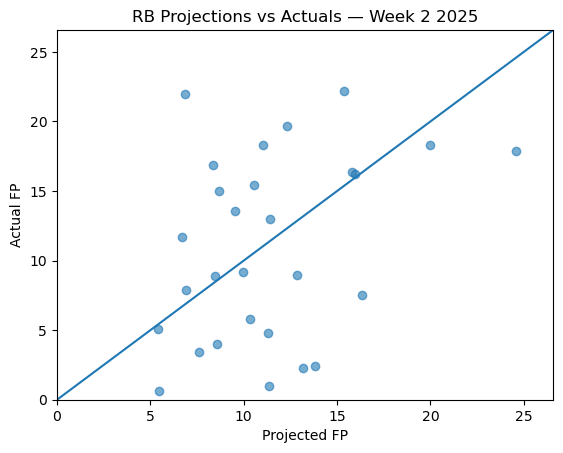

In [27]:
# Cell 16 — Persist results and visualize

from pathlib import Path
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

csv_path = out_dir / f"rb_week{TARGET_WEEK}_{TARGET_SEASON}_scored.csv"
scored.to_csv(csv_path, index=False)
print("Saved:", csv_path)

# Simple scatter plot (matplotlib only; no seaborn; single chart; no custom colors)
import matplotlib.pyplot as plt

if not scored.empty:
    plt.figure()
    plt.scatter(scored["proj_fp"], scored["actual_fp"], alpha=0.6)
    plt.xlabel("Projected FP")
    plt.ylabel("Actual FP")
    plt.title(f"RB Projections vs Actuals — Week {TARGET_WEEK} {TARGET_SEASON}")
    # 45° reference line
    max_lim = max(scored["proj_fp"].max(), scored["actual_fp"].max()) + 2
    plt.plot([0, max_lim], [0, max_lim])
    plt.xlim(0, max_lim)
    plt.ylim(0, max_lim)
    plt.show()
else:
    print("Skipped plot: no matched rows in 'scored'.")

In [28]:
# Cell 17 — Classification metrics for "Start" as projected top-24

import numpy as np
import pandas as pd

if "tier" not in scored.columns:
    scored = scored.copy()
    scored["tier"] = pd.cut(
        scored["proj_fp"].rank(ascending=False, method="first"),
        bins=[0,24,36,60,1e9],
        labels=["Start","Stream","Stash","Sit"]
    )

s = scored.copy()
s["is_pred_start"] = s["tier"].eq("Start")
s["rank_act"]      = s["actual_fp"].rank(ascending=False, method="first")
s["is_act_top24"]  = s["rank_act"] <= 24

TP = int(((s["is_pred_start"]) & (s["is_act_top24"])).sum())
FP = int(((s["is_pred_start"]) & (~s["is_act_top24"])).sum())
FN = int((~s["is_pred_start"]  &  (s["is_act_top24"])).sum())
TN = int((~s["is_pred_start"]  & (~s["is_act_top24"])).sum())

precision = TP / (TP + FP) if (TP + FP) else float("nan")
recall    = TP / (TP + FN) if (TP + FN) else float("nan")
f1        = (2*precision*recall)/(precision+recall) if precision==precision and recall==recall and (precision+recall)>0 else float("nan")

print("Confusion matrix (pred Start vs actual top-24):")
print(pd.DataFrame(
    [[TP, FP],
     [FN, TN]],
    index=["Actual Top-24","Actual 25+"],
    columns=["Pred Start","Pred Not-Start"]
))
print(f"\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Confusion matrix (pred Start vs actual top-24):
               Pred Start  Pred Not-Start
Actual Top-24          15               3
Actual 25+              9               1

Precision: 0.833 | Recall: 0.625 | F1: 0.714


In [29]:
# Cell 18 — Fit a simple linear calibrator and preview its effect

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import joblib
import numpy as np

X = scored[["proj_fp"]].values
y = scored["actual_fp"].values

cal = LinearRegression().fit(X, y)
a, b = float(cal.intercept_), float(cal.coef_[0])
print(f"Calibrator: actual ≈ a + b·proj  →  a={a:.3f}, b={b:.3f}")

# Preview calibrated metrics on this week
scored_cal = scored.copy()
scored_cal["proj_fp_cal"] = cal.predict(X)

mae  = mean_absolute_error(scored_cal["actual_fp"], scored_cal["proj_fp"])
rmse = mean_squared_error(scored_cal["actual_fp"], scored_cal["proj_fp"], squared=False)
r2   = r2_score(scored_cal["actual_fp"], scored_cal["proj_fp"])

mae_c  = mean_absolute_error(scored_cal["actual_fp"], scored_cal["proj_fp_cal"])
rmse_c = mean_squared_error(scored_cal["actual_fp"], scored_cal["proj_fp_cal"], squared=False)
r2_c   = r2_score(scored_cal["actual_fp"], scored_cal["proj_fp_cal"])

print("\nOriginal vs Calibrated (this week):")
print(f"  MAE  : {mae:.3f} → {mae_c:.3f}")
print(f"  RMSE : {rmse:.3f} → {rmse_c:.3f}")
print(f"  R^2  : {r2:.3f} → {r2_c:.3f}")

# Save calibrator (you can optionally load/apply it inside predict_week)
Path(MODELDIR).mkdir(exist_ok=True, parents=True)
joblib.dump(cal, Path(MODELDIR)/f"rb_calibrator_w{TARGET_WEEK}_{TARGET_SEASON}.joblib")
print("Saved calibrator →", Path(MODELDIR)/f"rb_calibrator_w{TARGET_WEEK}_{TARGET_SEASON}.joblib")

Calibrator: actual ≈ a + b·proj  →  a=5.037, b=0.526

Original vs Calibrated (this week):
  MAE  : 5.315 → 5.220
  RMSE : 6.516 → 6.171
  R^2  : 0.019 → 0.120
Saved calibrator → models\rb_calibrator_w2_2025.joblib


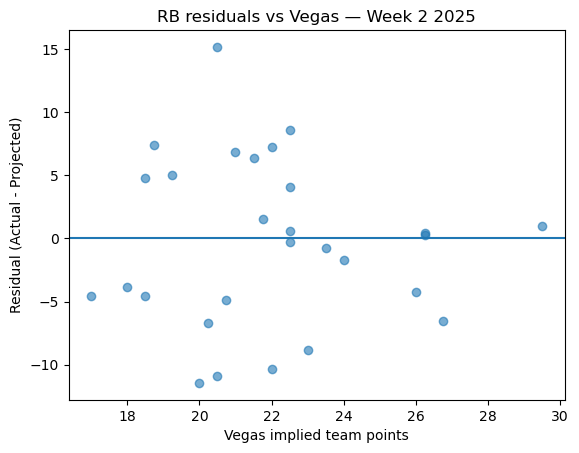

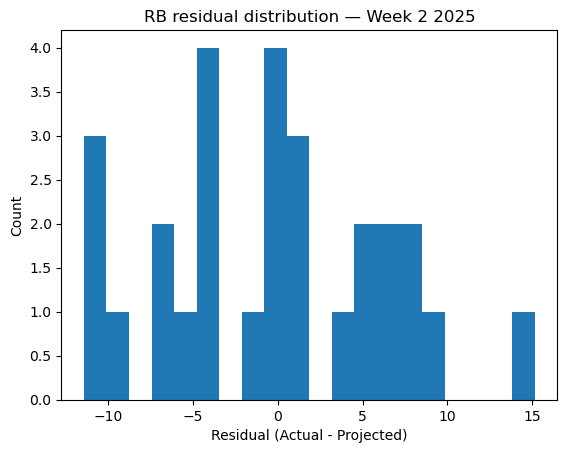

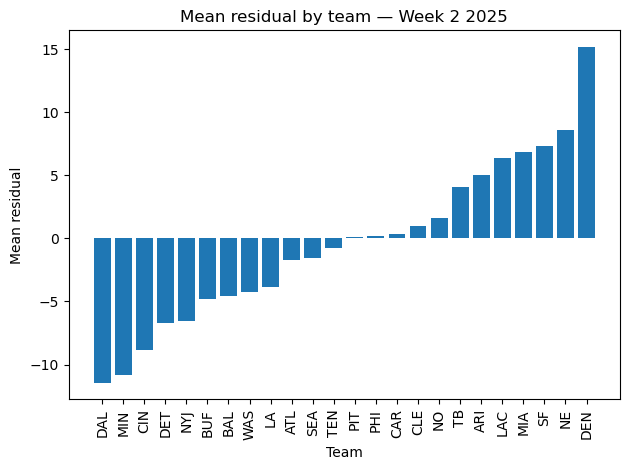

In [30]:
# Cell 19 — Residuals vs Vegas & residual distribution

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

diag = scored.copy()
diag["resid"] = diag["actual_fp"] - diag["proj_fp"]

# 1) Residuals vs Vegas implied points (if available)
if "vegas_implied_pts" in diag.columns and diag["vegas_implied_pts"].notna().any():
    plt.figure()
    plt.scatter(diag["vegas_implied_pts"], diag["resid"], alpha=0.6)
    plt.axhline(0)
    plt.xlabel("Vegas implied team points")
    plt.ylabel("Residual (Actual - Projected)")
    plt.title(f"RB residuals vs Vegas — Week {TARGET_WEEK} {TARGET_SEASON}")
    plt.show()
else:
    print("Skip plot: no vegas_implied_pts available in 'scored'.")

# 2) Residual histogram
plt.figure()
plt.hist(diag["resid"].dropna().values, bins=20)
plt.xlabel("Residual (Actual - Projected)")
plt.ylabel("Count")
plt.title(f"RB residual distribution — Week {TARGET_WEEK} {TARGET_SEASON}")
plt.show()

# 3) Per-team mean residuals (bar)
team_resid = (diag.groupby("team", as_index=False)["resid"].mean().sort_values("resid"))
plt.figure()
plt.bar(team_resid["team"], team_resid["resid"])
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Mean residual")
plt.title(f"Mean residual by team — Week {TARGET_WEEK} {TARGET_SEASON}")
plt.tight_layout()
plt.show()

In [31]:
# Cell 20 — Persist headline metrics/overlaps into a CSV log

from pathlib import Path
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from scipy.stats import spearmanr
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# Recompute headline metrics to store cleanly
mae  = mean_absolute_error(scored["actual_fp"], scored["proj_fp"])
rmse = mean_squared_error(scored["actual_fp"], scored["proj_fp"], squared=False)
r2   = r2_score(scored["actual_fp"], scored["proj_fp"])
if _HAS_SCIPY:
    rho, rho_p = spearmanr(scored["actual_fp"], scored["proj_fp"])
else:
    rho, rho_p = float("nan"), float("nan")

# Overlaps
def _overlap(sdf, N):
    s = sdf.copy()
    s["rank_pred"] = s["proj_fp"].rank(ascending=False, method="first")
    s["rank_act"]  = s["actual_fp"].rank(ascending=False, method="first")
    top_pred = set(s.nsmallest(N, "rank_pred").index)
    top_act  = set(s.nsmallest(N, "rank_act").index)
    return len(top_pred & top_act)

top12 = _overlap(scored, 12)
top24 = _overlap(scored, 24)
top36 = _overlap(scored, 36)

# Start tier precision/recall
if "tier" not in scored.columns:
    scored = scored.copy()
    scored["tier"] = pd.cut(scored["proj_fp"].rank(ascending=False, method="first"),
                            bins=[0,24,36,60,1e9], labels=["Start","Stream","Stash","Sit"])
sc = scored.copy()
sc["is_pred_start"] = sc["tier"].eq("Start")
sc["rank_act"]      = sc["actual_fp"].rank(ascending=False, method="first")
sc["is_act_top24"]  = sc["rank_act"] <= 24
TP = int(((sc["is_pred_start"]) & (sc["is_act_top24"])).sum())
FP = int(((sc["is_pred_start"]) & (~sc["is_act_top24"])).sum())
FN = int((~sc["is_pred_start"]  &  (sc["is_act_top24"])).sum())

prec = TP / (TP + FP) if (TP + FP) else float("nan")
rec  = TP / (TP + FN) if (TP + FN) else float("nan")

log_row = pd.DataFrame([{
    "season": TARGET_SEASON,
    "week": TARGET_WEEK,
    "mae": mae, "rmse": rmse, "r2": r2,
    "spearman": rho,
    "top12_overlap": top12,
    "top24_overlap": top24,
    "top36_overlap": top36,
    "start_precision": prec,
    "start_recall": rec,
    "n_scored": int(len(scored))
}])

out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
log_path = out_dir / "rb_metrics_log.csv"

if log_path.exists():
    prev = pd.read_csv(log_path)
    new  = pd.concat([prev, log_row], ignore_index=True)
    new.to_csv(log_path, index=False)
else:
    log_row.to_csv(log_path, index=False)

print("Updated metrics log →", log_path)

Updated metrics log → outputs\rb_metrics_log.csv
